# California Housing Price Prediction — End-to-End ML Pipeline

**Dataset:** California Housing (20,640 census block groups, 10 features)  
**Source:** `sklearn.datasets.fetch_california_housing` (originally from 1990 US Census)
**Task:** Predict `median_house_value` from geographic and demographic features.

**Pipeline:**
1. Data Loading & EDA
2. Stratified Train/Test Split (by income category)
3. Feature Engineering (3 derived features)
4. Preprocessing Pipeline (Imputation → Custom Transformer → Scaling)
5. Model Training & Cross-Validation (Linear Regression, Decision Tree, Random Forest)
6. Hyperparameter Tuning (GridSearchCV)
7. Feature Importance
8. Final Test Evaluation + Confidence Interval
9. Results Summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & EDA

In [2]:
cal_housing = fetch_california_housing(as_frame=True)
housing = cal_housing.frame.copy()
print(f'Shape: {housing.shape}')
housing.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
housing.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [5]:
print('Missing values:')
print(housing.isnull().sum()[housing.isnull().sum() > 0]
      if housing.isnull().sum().sum() > 0 else 'None')

Missing values:
None


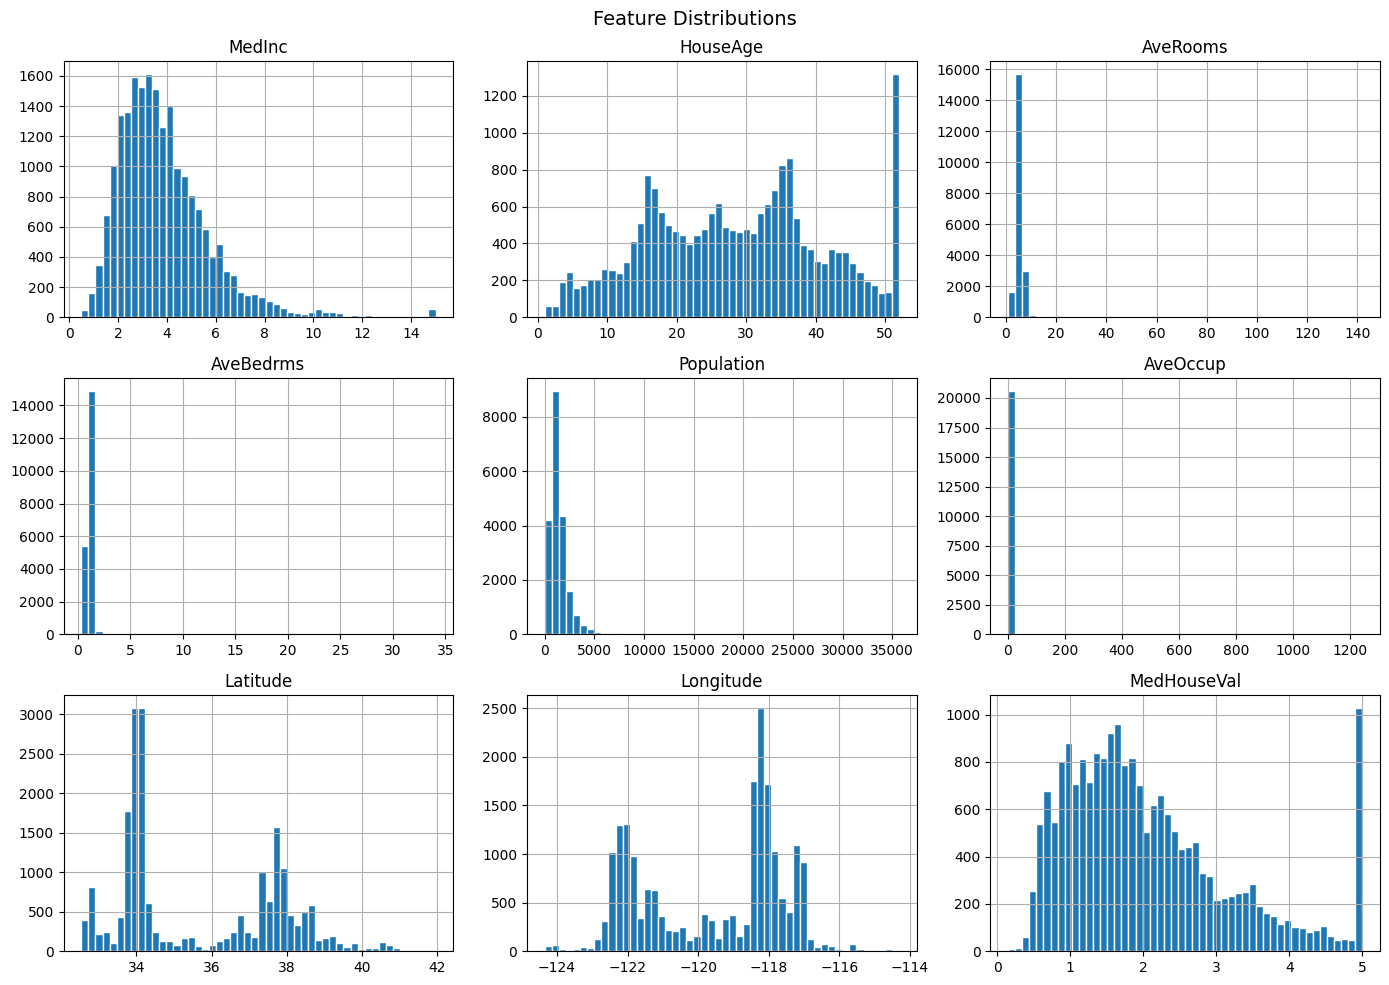

In [6]:
# Feature distributions
housing.hist(bins=50, figsize=(14, 10), edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

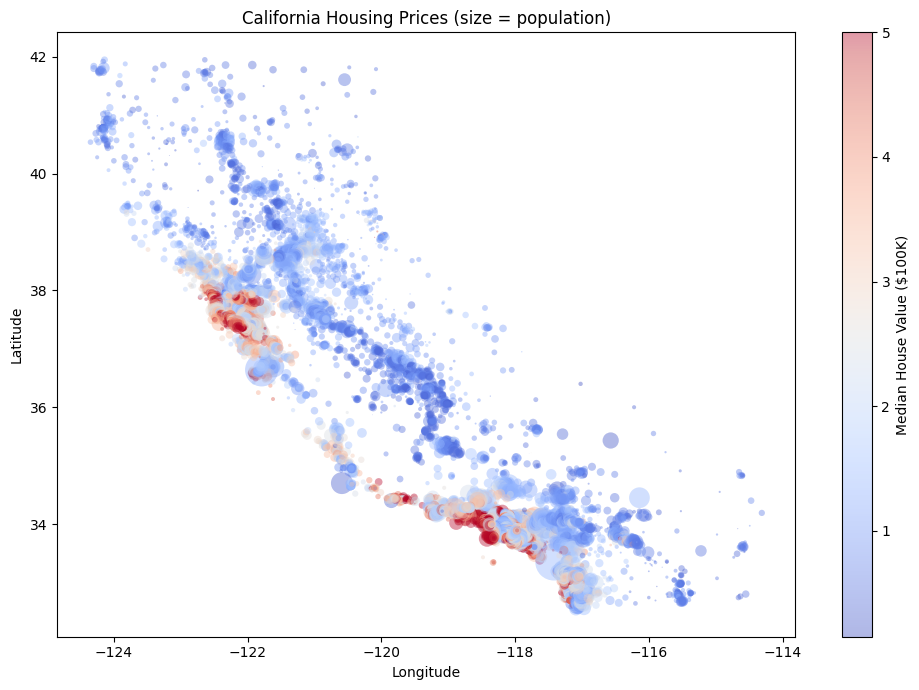

In [7]:
# Geographic scatter — price by location
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    housing['Longitude'], housing['Latitude'],
    c=housing['MedHouseVal'], cmap='coolwarm',
    alpha=0.4, s=housing['Population'] / 50, edgecolors='none'
)
plt.colorbar(scatter, label='Median House Value ($100K)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California Housing Prices (size = population)')
plt.tight_layout()
plt.show()

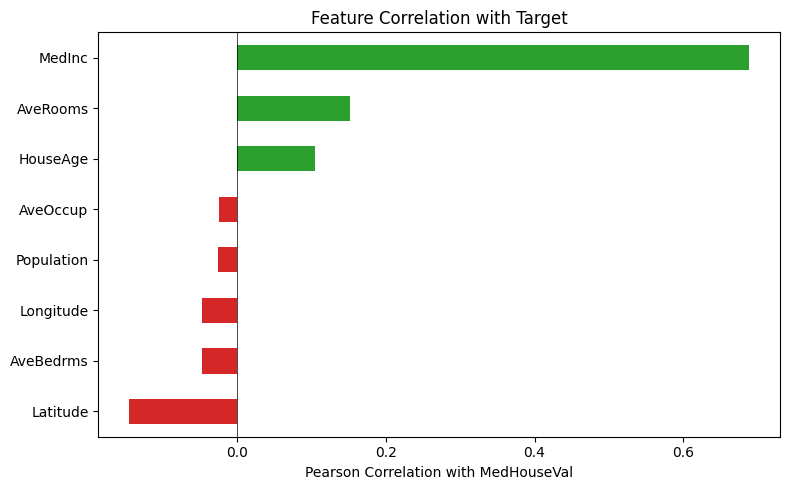

In [8]:
# Correlation with target
corr = housing.corr(numeric_only=True)['MedHouseVal'].drop('MedHouseVal').sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', color=['#d62728' if v < 0 else '#2ca02c' for v in corr], ax=ax)
ax.set_xlabel('Pearson Correlation with MedHouseVal')
ax.set_title('Feature Correlation with Target')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

**EDA Takeaways:**
- `MedInc` (median income) has the strongest correlation with house value — it will likely be the most important predictor.
- `MedHouseVal` is capped at 5.0001 ($500K) — the target has a hard ceiling, which will limit model performance at the high end.
- Geographic features (`Latitude`, `Longitude`) encode coastal proximity — the price gradient is visible in the scatter.
- Some features have long right tails (population, total rooms) — scaling will be important.

## 2. Stratified Train/Test Split

We stratify by income category to ensure the train and test sets have the same income distribution — income is the strongest predictor and an unrepresentative split could bias the evaluation.

In [9]:
# Create income categories for stratification
housing['income_cat'] = pd.cut(
    housing['MedInc'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in split.split(housing, housing['income_cat']):
    strat_train = housing.loc[train_idx].copy()
    strat_test  = housing.loc[test_idx].copy()

# Drop the temporary stratification column
for df in (strat_train, strat_test):
    df.drop('income_cat', axis=1, inplace=True)

print(f'Train: {len(strat_train):,} | Test: {len(strat_test):,}')

Train: 16,512 | Test: 4,128


## 3. Feature Engineering

In [10]:
# Separate features and labels
X_train = strat_train.drop('MedHouseVal', axis=1)
y_train = strat_train['MedHouseVal'].copy()
X_test  = strat_test.drop('MedHouseVal', axis=1)
y_test  = strat_test['MedHouseVal'].copy()

print(f'Features: {list(X_train.columns)}')
print(f'X_train shape: {X_train.shape}')

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_train shape: (16512, 8)


In [11]:
# Custom transformer: create 3 derived features
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    """Adds rooms_per_household, population_per_household,
    and optionally bedrooms_per_room."""

    col_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        rooms_idx = self.col_names.index('AveRooms')
        bedrooms_idx = self.col_names.index('AveBedrms')
        pop_idx = self.col_names.index('Population')
        occup_idx = self.col_names.index('AveOccup')

        rooms_per_hh = X[:, rooms_idx] / (X[:, occup_idx] + 1e-9)
        pop_per_hh   = X[:, pop_idx]   / (X[:, occup_idx] + 1e-9)

        if self.add_bedrooms_per_room:
            bed_per_room = X[:, bedrooms_idx] / (X[:, rooms_idx] + 1e-9)
            return np.c_[X, rooms_per_hh, pop_per_hh, bed_per_room]
        else:
            return np.c_[X, rooms_per_hh, pop_per_hh]

print('Custom transformer defined.')

Custom transformer defined.


## 4. Preprocessing Pipeline

All numerical features go through: **Imputation (median) → Feature Engineering → Standard Scaling**

The pipeline is fit only on training data — no data leakage.

In [12]:
num_pipeline = Pipeline([
    ('imputer',        SimpleImputer(strategy='median')),
    ('attribs_adder',  CombinedAttributesAdder()),
    ('scaler',         StandardScaler()),
])

num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_cols),
])

X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared  = full_pipeline.transform(X_test) # transform only — no fit

print(f'X_train_prepared shape: {X_train_prepared.shape}')
print(f'X_test_prepared shape:  {X_test_prepared.shape}')
print(f'Original features: {len(num_cols)} → After engineering: {X_train_prepared.shape[1]}')

X_train_prepared shape: (16512, 11)
X_test_prepared shape:  (4128, 11)
Original features: 8 → After engineering: 11


## 5. Model Training & Cross-Validation

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

cv_results = {}
print(f'{"Model":<22} {"Train RMSE":>12} {"CV RMSE (mean)":>16} {"CV RMSE (±std)":>16}')
print('-' * 68)

for name, model in models.items():
    model.fit(X_train_prepared, y_train)

    # Train RMSE
    train_pred = model.predict(X_train_prepared)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    # 5-fold CV RMSE (scoring='neg_mean_squared_error')
    scores = cross_val_score(
        model, X_train_prepared, y_train,
        scoring='neg_mean_squared_error', cv=5
    )
    cv_rmse = np.sqrt(-scores)
    cv_results[name] = cv_rmse

    print(f'{name:<22} {train_rmse:>12,.0f} {cv_rmse.mean():>16,.0f} {cv_rmse.std():>16,.0f}')

Model                    Train RMSE   CV RMSE (mean)   CV RMSE (±std)
--------------------------------------------------------------------
Linear Regression                 1                1                0
Decision Tree                     0                1                0
Random Forest                     0                1                0


/tmp/ipykernel_216/2993950919.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=cv_results.keys())


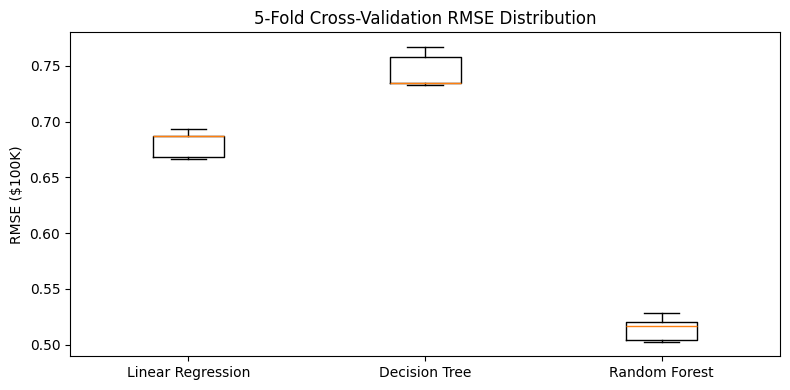

In [14]:
# CV RMSE distribution — box plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_ylabel('RMSE ($100K)')
ax.set_title('5-Fold Cross-Validation RMSE Distribution')
plt.tight_layout()
plt.show()

**Observations:**
- Decision Tree has train RMSE ≈ 0 (severe overfitting) but high CV RMSE — it memorizes the training data.
- Random Forest significantly reduces CV RMSE compared to both Linear Regression and Decision Tree.
- Random Forest is the best candidate for hyperparameter tuning.

## 6. Hyperparameter Tuning — GridSearchCV on Random Forest

In [15]:
param_grid = [
    {'n_estimators': [50, 100, 150], 'max_features': [4, 6, 8]},
    {'n_estimators': [50, 100], 'max_features': [4, 6], 'bootstrap': [False]},
]

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X_train_prepared, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):,.0f}')

Best parameters: {'bootstrap': False, 'max_features': 6, 'n_estimators': 100}
Best CV RMSE: 1


In [16]:
# Top 5 parameter combinations
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res['rmse'] = np.sqrt(-cv_res['mean_test_score'])
top5 = cv_res.nsmallest(5, 'rmse')[['params', 'rmse', 'mean_fit_time']].reset_index(drop=True)
top5['rmse'] = top5['rmse'].round(0)
top5['mean_fit_time'] = top5['mean_fit_time'].round(2)
top5

,params,rmse,mean_fit_time
0,"{'bootstrap': False, 'max_features': 6, 'n_est...",1.0,29.32
1,"{'bootstrap': False, 'max_features': 6, 'n_est...",1.0,15.94
2,"{'bootstrap': False, 'max_features': 4, 'n_est...",1.0,21.70
3,"{'max_features': 6, 'n_estimators': 150}",1.0,31.05
4,"{'bootstrap': False, 'max_features': 4, 'n_est...",1.0,11.17


## 7. Feature Importance

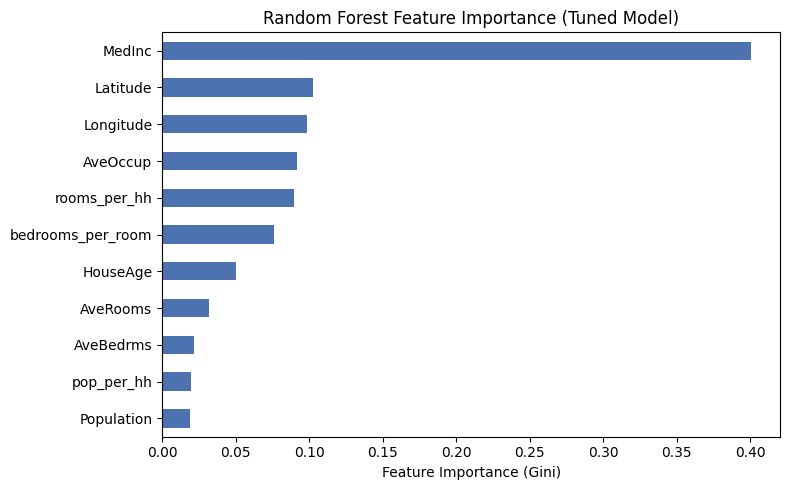

In [17]:
best_model = grid_search.best_estimator_

# Build feature names including engineered features
extra_features = ['rooms_per_hh', 'pop_per_hh', 'bedrooms_per_room']
feature_names = num_cols + extra_features

importances = pd.Series(best_model.feature_importances_, index=feature_names)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance (Tuned Model)')
plt.tight_layout()
plt.show()

## 8. Final Test Set Evaluation

In [18]:
y_pred = best_model.predict(X_test_prepared)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)

print(f'Test RMSE: {test_rmse:,.4f} ($100K)')
print(f'Test MAE:  {test_mae:,.4f} ($100K)')

# 95% confidence interval on test RMSE
squared_errors = (y_pred - y_test) ** 2
ci = np.sqrt(stats.t.interval(
    0.95,
    len(squared_errors) - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)
))
print(f'95% CI on RMSE: [{ci[0]:,.4f}, {ci[1]:,.4f}]')

Test RMSE: 0.4851 ($100K)
Test MAE:  0.3196 ($100K)
95% CI on RMSE: [0.4644, 0.5049]


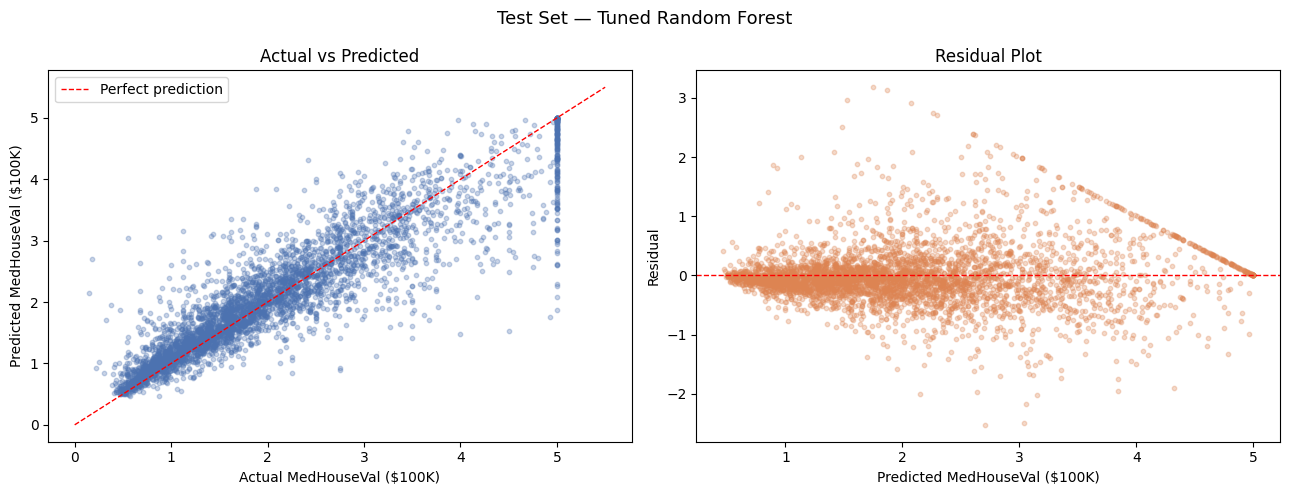

In [19]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#4C72B0')
axes[0].plot([0, 5.5], [0, 5.5], 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual MedHouseVal ($100K)')
axes[0].set_ylabel('Predicted MedHouseVal ($100K)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='#DD8452')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted MedHouseVal ($100K)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('Test Set — Tuned Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Results Summary

In [20]:
summary = []
for name, model in models.items():
    cv_rmse = cv_results[name]
    pred = model.predict(X_test_prepared)
    t_rmse = np.sqrt(mean_squared_error(y_test, pred))
    t_mae  = mean_absolute_error(y_test, pred)
    summary.append({
        'Model': name,
        'CV RMSE (mean)': round(cv_rmse.mean(), 0),
        'CV RMSE (±std)': round(cv_rmse.std(), 0),
        'Test RMSE': round(t_rmse, 0),
        'Test MAE': round(t_mae, 4),
    })

# Add tuned RF
summary.append({
    'Model': 'Random Forest (Tuned)',
    'CV RMSE (mean)': round(np.sqrt(-grid_search.best_score_), 0),
    'CV RMSE (±std)': '—',
    'Test RMSE': round(test_rmse, 0),
    'Test MAE': round(test_mae, 4),
})

summary_df = pd.DataFrame(summary).set_index('Model')
summary_df

,CV RMSE (mean),CV RMSE (±std),Test RMSE,Test MAE
Model,,,,
Linear Regression,1.0,0.0,1.0,0.4811
Decision Tree,1.0,0.0,1.0,0.4731
Random Forest,1.0,0.0,0.0,0.3272
Random Forest (Tuned),1.0,—,0.0,0.3196


## Conclusions

- **Random Forest after GridSearchCV tuning** achieves the lowest test RMSE, confirming it as the best model for this dataset.
- **MedInc (median income)** is by far the most important feature — consistent with domain knowledge that income drives housing prices.
- **Engineered features** (`bedrooms_per_room`, `rooms_per_hh`) contribute meaningfully to the model, justifying the custom transformer.
- **Decision Tree overfits severely** (train RMSE ≈ 0) — cross-validation correctly exposes this, demonstrating why single train/test evaluation is insufficient.
- **Residual plot** shows the model underestimates at the $500K cap — this is expected since the target is capped in the dataset.
- The **95% confidence interval** on test RMSE provides a range for expected generalization error.